In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 68.7 MB/s eta 0:00:00


In [ ]:
!unzip /content/Bank+Customer+Churn.zip

Archive:  /content/Bank+Customer+Churn.zip
  inflating: Bank_Churn.csv          
  inflating: Bank_Churn_Data_Dictionary.csv  
  inflating: Bank_Churn_Messy.xlsx   


#Tables
Bank Churn

#Data Collection
Maven Data analysis

#Data Cleaning
- Checking NaN Values
- Checking Unique Values
- Data Formatting


# Planning
###High Level Analysis
- Total Customers → Count of all customers in the dataset.
- Total Sales / Revenue → Sum of balances, deposits, or product fees (depending on available data).
- Average Customer Lifetime Value (CLV) → Estimated revenue per customer over tenure.
- Customer Demographics → Age distribution, geographic breakdown.
- Overall Churn Rate → % of customers who exited.
- Credit Score Distribution → Risk profile across the customer base
###Operational Analysis

- Active Customers → % of customers marked as active members.
- Active Cust by Geography
- Product Ownership → Average number of products per customer;
- Transaction Frequency → Number of transactions per month (if available).
- Risk Monitoring → % of customers with credit scores below a threshold (e.g., 600).
-Cust by Risk Level
- Customer Tenure → Average years with the bank, useful for loyalty analysis.- - Average tenure for churned vs retained customers
- Churn by Active Membership
- Product Ownership vs. Churn


In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore")




In [ ]:
df1 = pd.read_csv('/content/Bank_Churn.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [ ]:
df1.info()
df1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df1['Tenure'].unique()

array([ 2,  1,  8,  7,  4,  6,  3, 10,  5,  9,  0])

In [ ]:
ten = df1.groupby(['CustomerId'])['Tenure'].mean()
ten

,Tenure
CustomerId,
15565701,9.0
15565706,1.0
15565714,1.0
15565779,6.0
15565796,10.0
...,...
15815628,8.0
15815645,8.0
15815656,9.0


###High Level Analysis


In [ ]:
#Total _Cust
t_cust = df1['CustomerId'].count()
t_cust

np.int64(10000)

In [ ]:
#Total_Sales/Revenue
t_sales = df1['Balance'].sum()
t_sales

np.float64(764858892.8800001)

In [ ]:
#Ave_Custmer Life Values
ave_clv = df1.groupby(['CustomerId', 'Tenure'])['Balance'].mean()
ave_clv.sort_values(ascending=False)

,,Balance
CustomerId,Tenure,
15757408,3,250898.09
15715622,3,238387.56
15714241,9,222267.63
15571958,3,221532.80
15586674,5,216109.88
...,...,...
15753754,1,0.00
15753679,4,0.00
15753591,2,0.00


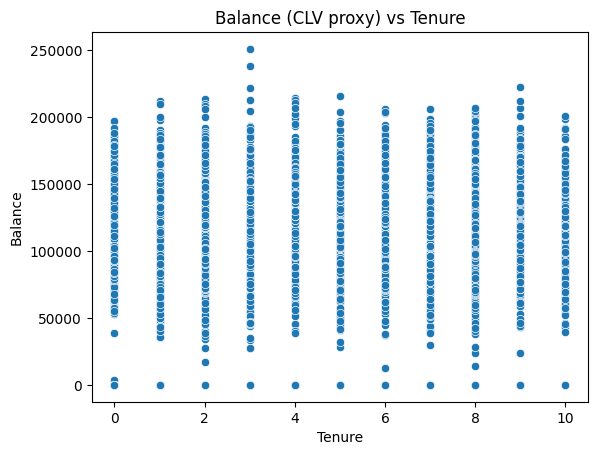

In [ ]:
sns.scatterplot(x='Tenure', y='Balance', data=df1)
plt.title('Balance (CLV proxy) vs Tenure')
plt.show()

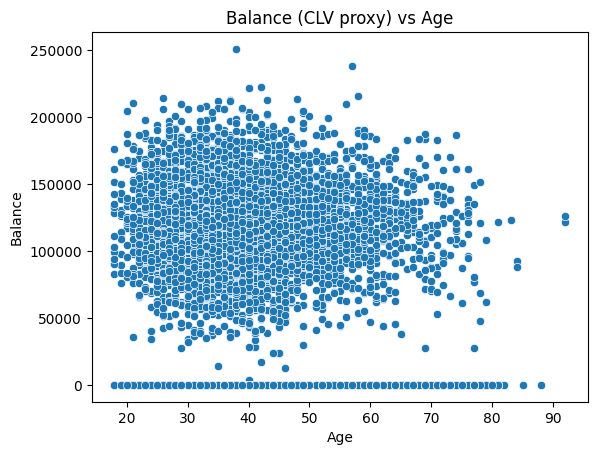

In [ ]:
sns.scatterplot(x='Age',y='Balance', data=df1)
plt.title('Balance (CLV proxy) vs Age')
plt.show()

In [ ]:
#Geo_Distribution
geo_dist = df1.groupby(['Geography'])['Balance'].sum()
geo_dist

,Balance
Geography,
France,3.113325e+08
Germany,3.004029e+08
Spain,1.531236e+08


In [ ]:
#Overall Churn Rate
churn_rate = df1['Exited'].mean()
churn_rate

np.float64(0.2037)

In [ ]:
# Churn rate by gender
churn_by_gender = df.groupby('Gender')['Exited'].mean() * 100
print(churn_by_gender)


Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64


In [ ]:
# Churn rate by geography
churn_by_geo = df.groupby('Geography')['Exited'].mean() * 100
print(churn_by_geo)


Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64


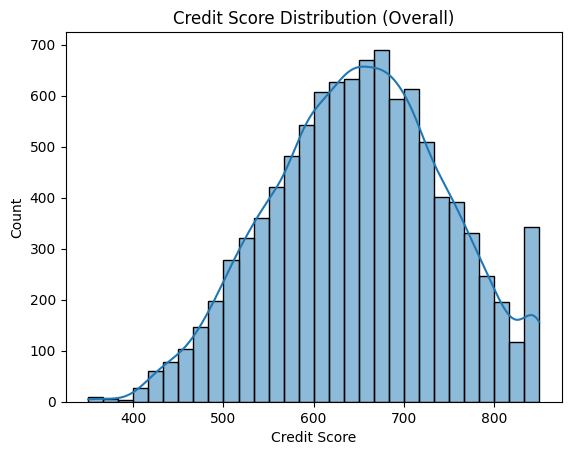

In [ ]:
sns.histplot(df1['CreditScore'], bins=30, kde=True)
plt.title("Credit Score Distribution (Overall)")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.show()


###Operational Analysis

In [ ]:
#Active_Cust
act_cust = df1['IsActiveMember'].mean()
act_cust


np.float64(0.5151)

In [ ]:
#Active_Cust_by_Geo
act_cust_gp = df1.pivot_table(index='Geography', columns='IsActiveMember', values='CustomerId', aggfunc='count')
act_cust_gp

IsActiveMember,0,1
Geography,,
France,2423,2591
Germany,1261,1248
Spain,1165,1312


In [ ]:
#Product_Ownership
prod_own = df1.groupby(['CustomerId'])['NumOfProducts'].sum()
prod_own.sort_values(ascending=False)

,NumOfProducts
CustomerId,
15608338,4
15570002,4
15640846,4
15568006,4
15610383,4
...,...
15815615,1
15815560,1
15815552,1


In [ ]:
df1['RiskLevel'] = pd.cut(df1['CreditScore'],
                         bins=[0,600,700,850],
                         labels=['High Risk','Medium Risk','Low Risk'])



RiskLevel
Medium Risk    38.18
Low Risk       31.16
High Risk      30.66
Name: proportion, dtype: float64


In [ ]:
#Risk Monitoring
risk_mon = df1.groupby(['CustomerId'])['CreditScore'].mean()
risk_mon.sort_values(ascending=False)


,CreditScore
CustomerId,
15815095,850.0
15662100,850.0
15595221,850.0
15768201,850.0
15768219,850.0
...,...
15803202,350.0
15685372,350.0
15758813,350.0


In [ ]:
#Cust by Risk level
cust_risk = df1.groupby(['RiskLevel'])['CustomerId'].count()
cust_risk

/tmp/ipython-input-250/347812544.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cust_risk = df1.groupby(['RiskLevel'])['CustomerId'].count()


,CustomerId
RiskLevel,
High Risk,3066
Medium Risk,3818
Low Risk,3116


In [ ]:
# Average tenure across all customers
avg_tenure = df1['Tenure'].mean()
print(f"Average Tenure: {avg_tenure:.2f} years")

Average Tenure: 5.01 years


In [ ]:
# Average tenure for churned vs retained customers
tenure_churn = df1.groupby('Exited')['Tenure'].mean()
print(tenure_churn)


Exited
0    5.033279
1    4.932744
Name: Tenure, dtype: float64


In [ ]:
#Predictive Modeling (Churn)
X = df1[['Balance', 'NumOfProducts', 'Tenure']]
y = df1['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.88      0.86      2416
           1       0.35      0.27      0.31       584

    accuracy                           0.76      3000
   macro avg       0.59      0.58      0.58      3000
weighted avg       0.74      0.76      0.75      3000



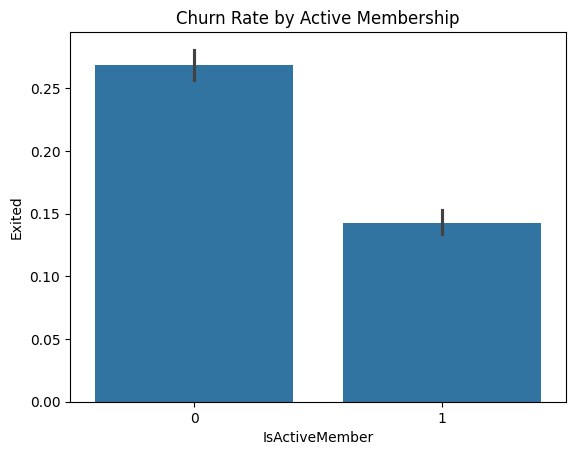

In [ ]:
# Churn by Active Membership
sns.barplot(x='IsActiveMember', y='Exited', data=df1)
plt.title("Churn Rate by Active Membership")
plt.show()


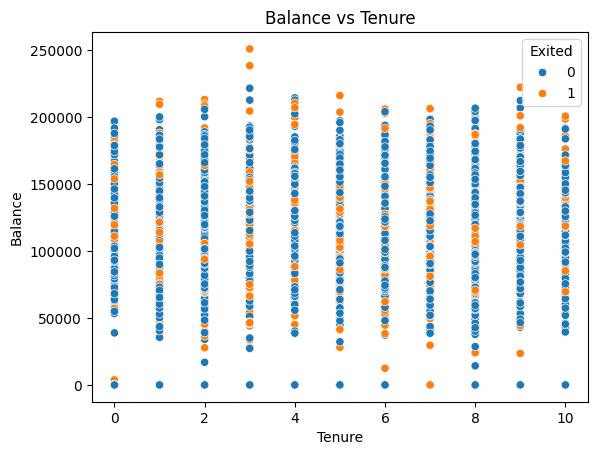

In [ ]:
# Balance vs Tenure

sns.scatterplot(x='Tenure', y='Balance', hue='Exited', data=df1)
plt.title("Balance vs Tenure")
plt.show()


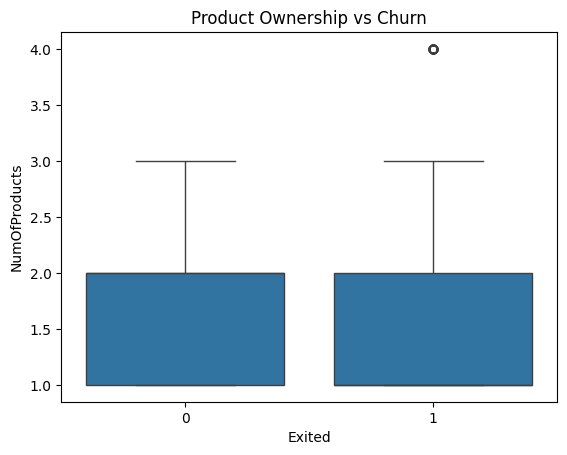

In [ ]:
# Product Ownership vs. Churn
sns.boxplot(x='Exited', y='NumOfProducts', data=df1)
plt.title("Product Ownership vs Churn")
plt.show()



In [ ]:
# % of customers with Balance = 0 → potential disengagement
# % of customers with NumOfProducts = 1 → cross-sell opportunity

zero_balance_pct = (df1['Balance'] == 0).mean() * 100
low_product_pct = (df1['NumOfProducts'] == 1).mean() * 100
print(f"Zero Balance Customers: {zero_balance_pct:.2f}%")
print(f"Single Product Customers: {low_product_pct:.2f}%")


Zero Balance Customers: 36.17%
Single Product Customers: 50.84%


### Streamlit

In [ ]:

# Load dataset
df1 = pd.read_csv("Bank_Churn.csv")

# --- Sidebar Filters ---
st.sidebar.header("Filters")
geo_filter = st.sidebar.multiselect("Select Geography", options=df1['Geography'].unique())
active_filter = st.sidebar.selectbox("Active Member", options=["All", "Yes", "No"])

# Apply filters
df_filtered = df1.copy()
if geo_filter:
    df_filtered = df_filtered[df_filtered['Geography'].isin(geo_filter)]
if active_filter != "All":
    df_filtered = df_filtered[df_filtered['IsActiveMember'] == active_filter]

# --- Dashboard Title ---

st.title("📊 Bank Customer Churn Dashboard")

# --- High-Level KPIs ---
st.header("High-Level Metrics")
col1, col2, col3 = st.columns(3)

col1.metric("Total Customers", df_filtered['CustomerId'].nunique())
col2.metric("Total Balance", f"{df_filtered['Balance'].sum():,.2f}")
col3.metric("Churn Rate", f"{df_filtered['Exited'].mean()*100:.2f}%")

# --- Visualizations ---
st.header("Visualizations")

# Balance vs Tenure
st.subheader("Balance vs Tenure")
fig, ax = plt.subplots()
sns.scatterplot(x='Tenure', y='Balance', hue='Exited', data=df_filtered, ax=ax)
st.pyplot(fig)

# Credit Score Distribution
st.subheader("Credit Score Distribution")
fig, ax = plt.subplots()
sns.histplot(df_filtered['CreditScore'], bins=30, kde=True, ax=ax)
st.pyplot(fig)

# Churn by Active Membership
st.subheader("Churn by Active Membership")
fig, ax = plt.subplots()
sns.barplot(x='IsActiveMember', y='Exited', data=df_filtered, ax=ax)
st.pyplot(fig)

# Product Ownership vs Churn
st.subheader("Product Ownership vs Churn")
fig, ax = plt.subplots()
sns.boxplot(x='Exited', y='NumOfProducts', data=df_filtered, ax=ax)
st.pyplot(fig)

# Tenure vs Churn
st.subheader("Tenure vs Churn")
fig, ax = plt.subplots()
sns.boxplot(x='Exited', y='Tenure', data=df_filtered, ax=ax)
st.pyplot(fig)


2026-03-01 15:06:05.750 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 15:06:05.751 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 15:06:05.752 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 15:06:05.754 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 15:06:05.755 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 15:06:05.758 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 15:06:05.760 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-01 15:06:05.761 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()